<a href="https://colab.research.google.com/github/EddersonPR/challenge-telecomx-ml/blob/main/telecomx_machine_learning.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Objetivo Principal

Desarrollar modelos predictivos capaces de anticipar qué clientes tienen mayor probabilidad de cancelar sus servicios (churn), permitiendo a la empresa Telecom X para actuar preventivamente y reducir la evasión.

# Enfoque del Desafío

El reto consiste en transformar los datos previamente tratados en la fase anterior en un pipeline de modelado predictivo, que incluya la:

Preparación adicional de los datos.

Construcción y evaluación de modelos de clasificación.

Interpretación estratégica de los resultados.

In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

ModuleNotFoundError: No module named 'pandas'

In [ ]:
grafico = '/content/drive/MyDrive/CURSOS/ALURA/Challenge Telecom X - Machine Learning'

In [ ]:
url = 'https://raw.githubusercontent.com/Yul-79/Challenge-Telecom-Parte-2/refs/heads/main/data/datos_tratados.csv'
datos = pd.read_csv(url)
datos.head()

,CustomerID,Churn,Gender,SeniorCitizen,Partner,Dependents,Tenure,PhoneService,MultipleLines,InternetService,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,ChargesDaily,ChargesMonthly,ChargesTotal
0,0002-ORFBO,No,Female,No,Yes,Yes,9,Yes,No,DSL,...,No,Yes,Yes,No,One year,Yes,Mailed check,2.19,65.6,593.30
1,0003-MKNFE,No,Male,No,No,No,9,Yes,Yes,DSL,...,No,No,No,Yes,Month-to-month,No,Mailed check,2.00,59.9,542.40
2,0004-TLHLJ,Yes,Male,No,No,No,4,Yes,No,Fiber optic,...,Yes,No,No,No,Month-to-month,Yes,Electronic check,2.46,73.9,280.85
3,0011-IGKFF,Yes,Male,Yes,Yes,No,13,Yes,No,Fiber optic,...,Yes,No,Yes,Yes,Month-to-month,Yes,Electronic check,3.27,98.0,1237.85
4,0013-EXCHZ,Yes,Female,Yes,Yes,No,3,Yes,No,Fiber optic,...,No,Yes,Yes,No,Month-to-month,Yes,Mailed check,2.80,83.9,267.40


In [ ]:
datos.columns

Index(['CustomerID', 'Churn', 'Gender', 'SeniorCitizen', 'Partner',
       'Dependents', 'Tenure', 'PhoneService', 'MultipleLines',
       'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection',
       'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract',
       'PaperlessBilling', 'PaymentMethod', 'ChargesDaily', 'ChargesMonthly',
       'ChargesTotal'],
      dtype='object')

In [ ]:
datos.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 22 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   CustomerID        7043 non-null   object 
 1   Churn             7043 non-null   object 
 2   Gender            7043 non-null   object 
 3   SeniorCitizen     7043 non-null   object 
 4   Partner           7043 non-null   object 
 5   Dependents        7043 non-null   object 
 6   Tenure            7043 non-null   int64  
 7   PhoneService      7043 non-null   object 
 8   MultipleLines     7043 non-null   object 
 9   InternetService   7043 non-null   object 
 10  OnlineSecurity    7043 non-null   object 
 11  OnlineBackup      7043 non-null   object 
 12  DeviceProtection  7043 non-null   object 
 13  TechSupport       7043 non-null   object 
 14  StreamingTV       7043 non-null   object 
 15  StreamingMovies   7043 non-null   object 
 16  Contract          7043 non-null   object 


# Remover columna ID

In [ ]:
datos = datos.drop(columns=['CustomerID'])
datos.sample(5)

,Churn,Gender,SeniorCitizen,Partner,Dependents,Tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,ChargesDaily,ChargesMonthly,ChargesTotal
2797,No,Male,No,No,Yes,19,Yes,No,No,No,...,No,No,No,No,Two year,No,Credit card (automatic),0.70,20.85,467.50
1563,No,Male,Yes,Yes,No,72,No,No,DSL,Yes,...,Yes,Yes,Yes,Yes,Two year,Yes,Bank transfer (automatic),2.10,63.10,4685.55
2587,No,Male,No,Yes,Yes,7,Yes,No,DSL,Yes,...,No,No,Yes,Yes,Month-to-month,No,Credit card (automatic),2.32,69.70,516.15
2433,No,Male,No,No,Yes,21,Yes,Yes,No,No,...,No,No,No,No,Month-to-month,No,Mailed check,0.82,24.70,467.15
5231,No,Female,Yes,No,No,28,Yes,Yes,DSL,No,...,Yes,Yes,No,No,Month-to-month,No,Bank transfer (automatic),2.15,64.45,1867.60


# Normalización de valores "No internet service" a "No"

In [ ]:
cols_to_fix = [
    'OnlineSecurity', 'OnlineBackup', 'DeviceProtection',
    'TechSupport', 'StreamingTV', 'StreamingMovies'
]

for col in cols_to_fix:
    datos[col] = datos[col].replace({'No internet service': 'No'})


# Validación de nullos

In [ ]:
datos.isnull().sum()

,0
Churn,0
Gender,0
SeniorCitizen,0
Partner,0
Dependents,0
Tenure,0
PhoneService,0
MultipleLines,0
InternetService,0
OnlineSecurity,0


# Análisis Exploratorio de Datos (EDA)

# Análisis de correlación entre variables numericos

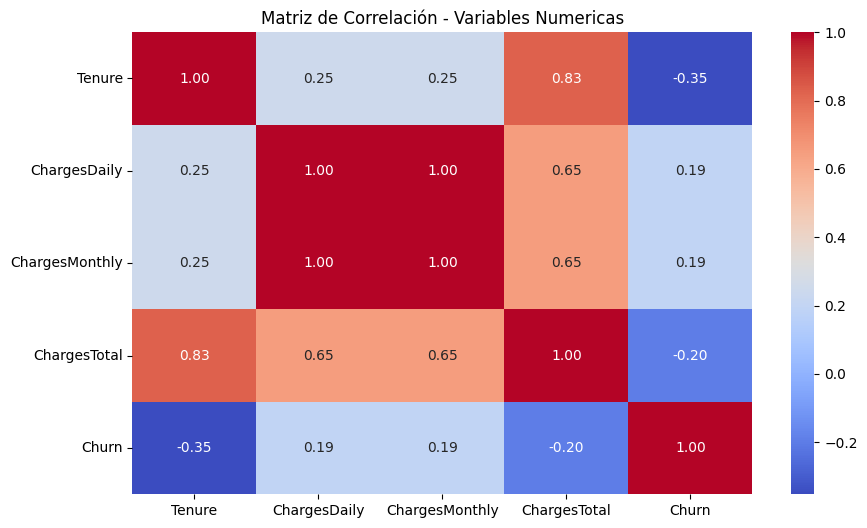

In [ ]:
datos_numericos = datos.select_dtypes(include=[np.number])
datos_numericos['Churn'] = datos['Churn'].map({"Yes":1, "No":0})
corr_matrix = datos_numericos.corr()

# Visualizar heatmap
plt.figure(figsize=(10,6))
sns.heatmap(corr_matrix, annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Matriz de Correlación - Variables Numericas")

# Guardar gráfico
plt.savefig(grafico +'/heatmap_correlacion.png', transparent=False, dpi=300, bbox_inches='tight')
plt.show()

# Tratamiento de Multicolinealidad
- Mantendremos 'ChargesMonthly' y 'Tenure' como los drivers principales

In [ ]:
# AGREGAR — justificación de multicolinealidad
print("Correlación entre variables numéricas:")
print(corr_matrix[['ChargesDaily', 'ChargesMonthly', 'ChargesTotal']].round(2))

# Decisión sustentada:
# ChargesDaily y ChargesTotal tienen correlación > 0.80 con ChargesMonthly
# Mantener las tres genera multicolinealidad → se conserva solo ChargesMonthly
# como representante del costo del cliente

datos = datos.drop(columns=['ChargesDaily', 'ChargesTotal'])
print("Columnas redundantes eliminadas por multicolinealidad")

Correlación entre variables numéricas:
                ChargesDaily  ChargesMonthly  ChargesTotal
Tenure                  0.25            0.25          0.83
ChargesDaily            1.00            1.00          0.65
ChargesMonthly          1.00            1.00          0.65
ChargesTotal            0.65            0.65          1.00
Churn                   0.19            0.19         -0.20
Columnas redundantes eliminadas por multicolinealidad


# Análisis de Churn por variables categoricas

In [ ]:
categorical_cols = datos.select_dtypes(include=["object"]).columns
categorical_cols = categorical_cols.drop("Churn")

In [ ]:
for col in categorical_cols:
    print(f"\n📌 Analisis de variable: {col}")
    display(pd.crosstab(datos[col], datos["Churn"], normalize="index") * 100)


📌 Analisis de variable: Gender


Churn,No,Yes
Gender,,
Female,73.079128,26.920872
Male,73.839662,26.160338



📌 Analisis de variable: SeniorCitizen


Churn,No,Yes
SeniorCitizen,,
No,76.393832,23.606168
Yes,58.318739,41.681261



📌 Analisis de variable: Partner


...

Churn,No,Yes
Contract,,
Month-to-month,57.290323,42.709677
One year,88.730482,11.269518
Two year,97.168142,2.831858



📌 Analisis de variable: PaperlessBilling


Churn,No,Yes
PaperlessBilling,,
No,83.669916,16.330084
Yes,66.434908,33.565092



📌 Analisis de variable: PaymentMethod


Churn,No,Yes
PaymentMethod,,
Bank transfer (automatic),83.290155,16.709845
Credit card (automatic),84.756899,15.243101
Electronic check,54.714588,45.285412
Mailed check,80.893300,19.106700


# Selección de Variables — Test Chi-Cuadrado

In [ ]:
from sklearn.preprocessing import LabelEncoder
from sklearn.feature_selection import chi2

# Crea copia
df_rank = datos.copy()

# Convertir Churn para binario
df_rank["Churn"] = df_rank["Churn"].map({"Yes": 1, "No": 0})

# Separar variables categóricas
categorical_cols = df_rank.select_dtypes(include=["object"]).columns

# Aplicar Label Encoding temporario
le = LabelEncoder()
for col in categorical_cols:
    df_rank[col] = le.fit_transform(df_rank[col])

# Separar X e y
X_cat = df_rank[categorical_cols]
y = df_rank["Churn"]

# Aplicar teste Qui-cuadrado
chi_scores, p_values = chi2(X_cat, y)

# Criar DataFrame com ranking
chi_df = pd.DataFrame({
    "Variable": categorical_cols,
    "Chi2 Score": chi_scores,
    "p-value": p_values
})

# Ordenar por importancia
chi_df = chi_df.sort_values(by="Chi2 Score", ascending=False)

chi_df


,Variable,Chi2 Score,p-value
13,Contract,1115.780167,1.227941e-244
7,OnlineSecurity,147.295858,6.761696e-34
10,TechSupport,135.559783,2.490549e-31
1,SeniorCitizen,134.351545,4.576959e-31
3,Dependents,133.036443,8.876729e-31
14,PaperlessBilling,105.680863,8.661987e-25
2,Partner,82.412083,1.104764e-19
15,PaymentMethod,58.492250,2.040933e-14
8,OnlineBackup,31.217694,2.306541e-08
9,DeviceProtection,20.226662,6.878750e-06


In [ ]:
significant_vars = chi_df[chi_df["p-value"] < 0.05]

print("\n Variables significativas (p < 0.05):")
display(significant_vars)



 Variables significativas (p < 0.05):


,Variable,Chi2 Score,p-value
13,Contract,1115.780167,1.227941e-244
7,OnlineSecurity,147.295858,6.761696e-34
10,TechSupport,135.559783,2.490549e-31
1,SeniorCitizen,134.351545,4.576959e-31
3,Dependents,133.036443,8.876729e-31
14,PaperlessBilling,105.680863,8.661987e-25
2,Partner,82.412083,1.104764e-19
15,PaymentMethod,58.492250,2.040933e-14
8,OnlineBackup,31.217694,2.306541e-08
9,DeviceProtection,20.226662,6.878750e-06


In [ ]:
datos = datos.drop(columns=["Gender", "PhoneService"])

# Partición del Dataset (Train / Test Split)

In [ ]:
X = datos.drop("Churn", axis=1)
y = datos["Churn"]

In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    stratify=y,
    random_state=42
)


# Codificación de Variables Categóricas (One-Hot Encoding)

In [ ]:
# Aplicar One-Hot Encoding en entrenamiento
X_train = pd.get_dummies(X_train, drop_first=True)

# Aplicar en testeo
X_test = pd.get_dummies(X_test, drop_first=True)

# Garantizar que entranmiento y testeo tengan las mismas columnas
X_train, X_test = X_train.align(X_test, join='left', axis=1, fill_value=0)

In [ ]:
X_train.head()

,Tenure,ChargesMonthly,SeniorCitizen_Yes,Partner_Yes,Dependents_Yes,MultipleLines_Yes,InternetService_Fiber optic,InternetService_No,OnlineSecurity_Yes,OnlineBackup_Yes,DeviceProtection_Yes,TechSupport_Yes,StreamingTV_Yes,StreamingMovies_Yes,Contract_One year,Contract_Two year,PaperlessBilling_Yes,PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check
3793,60,94.10,False,True,False,True,True,False,True,True,False,False,False,True,False,False,True,True,False,False
3192,12,19.35,False,False,True,False,False,True,False,False,False,False,False,False,False,True,False,False,False,False
4922,2,80.45,False,False,False,False,True,False,True,False,True,False,False,False,False,False,True,False,True,False
3926,33,74.75,False,True,True,False,False,False,True,False,True,False,True,True,True,False,False,True,False,False
3859,14,86.00,False,False,True,True,True,False,True,False,False,True,False,False,False,False,True,False,False,True


In [ ]:
X_train.info()

<class 'pandas.core.frame.DataFrame'>
Index: 5634 entries, 3793 to 5679
Data columns (total 20 columns):
 #   Column                                 Non-Null Count  Dtype  
---  ------                                 --------------  -----  
 0   Tenure                                 5634 non-null   int64  
 1   ChargesMonthly                         5634 non-null   float64
 2   SeniorCitizen_Yes                      5634 non-null   bool   
 3   Partner_Yes                            5634 non-null   bool   
 4   Dependents_Yes                         5634 non-null   bool   
 5   MultipleLines_Yes                      5634 non-null   bool   
 6   InternetService_Fiber optic            5634 non-null   bool   
 7   InternetService_No                     5634 non-null   bool   
 8   OnlineSecurity_Yes                     5634 non-null   bool   
 9   OnlineBackup_Yes                       5634 non-null   bool   
 10  DeviceProtection_Yes                   5634 non-null   bool   
 11  TechSu

# Análisis de Desbalance de Clases

In [ ]:
y_train.value_counts(normalize=True) * 100

,proportion
Churn,
No,73.464679
Yes,26.535321


# Entrenamiento de Modelos

## Modelo 1 — Regresión Logística (Baseline)

In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report

log_model_normal = LogisticRegression(max_iter=1000)
log_model_normal.fit(X_train, y_train)
y_pred_log_normal = log_model_normal.predict(X_test)

print("Regresion logistica")
print(classification_report(y_test, y_pred_log_normal))

Regresion logistica
              precision    recall  f1-score   support

          No       0.84      0.90      0.87      1035
         Yes       0.65      0.52      0.58       374

    accuracy                           0.80      1409
   macro avg       0.74      0.71      0.72      1409
weighted avg       0.79      0.80      0.79      1409



## Modelo 2 - Random Forest

In [ ]:
from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier(random_state=42)
rf_model.fit(X_train, y_train)

y_pred_rf = rf_model.predict(X_test)

print("Random Forest")
print(classification_report(y_test, y_pred_rf))

Random Forest
              precision    recall  f1-score   support

          No       0.83      0.90      0.86      1035
         Yes       0.62      0.48      0.54       374

    accuracy                           0.78      1409
   macro avg       0.72      0.69      0.70      1409
weighted avg       0.77      0.78      0.77      1409



## Modelo 3 — Regresión Logística (Balanceada)

In [ ]:
log_model_balanced = LogisticRegression(max_iter=1000, class_weight="balanced")
log_model_balanced.fit(X_train, y_train)
y_pred_log = log_model_balanced.predict(X_test)

print(classification_report(y_test, y_pred_log))

              precision    recall  f1-score   support

          No       0.90      0.73      0.81      1035
         Yes       0.51      0.79      0.62       374

    accuracy                           0.74      1409
   macro avg       0.71      0.76      0.71      1409
weighted avg       0.80      0.74      0.76      1409



# Evaluación — Matrices de Confusión

In [ ]:
from sklearn.metrics import confusion_matrix
# import matplotlib.pyplot as plt
# import numpy as np

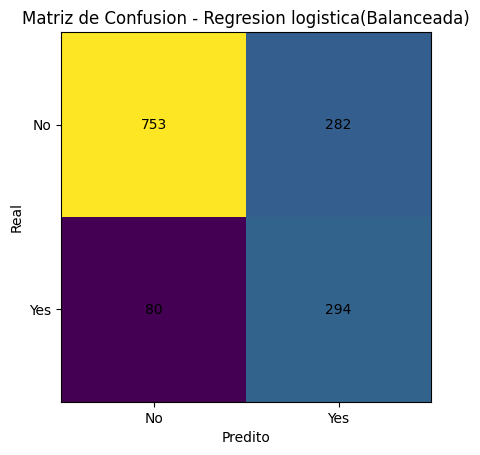

In [ ]:
cm = confusion_matrix(y_test, y_pred_log)

# Plot
plt.figure()
plt.imshow(cm)
plt.title("Matriz de Confusion - Regresion logistica(Balanceada)")
plt.xlabel("Predito")
plt.ylabel("Real")


for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        plt.text(j, i, cm[i, j], ha="center", va="center")

plt.xticks([0,1], ["No", "Yes"])
plt.yticks([0,1], ["No", "Yes"])

# Guardar gráfico
plt.savefig( grafico +'/matriz_confusion_balanced.png', transparent=False, dpi=300, bbox_inches='tight')

plt.show()

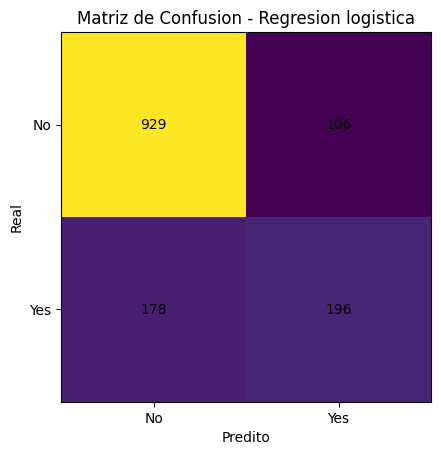

In [ ]:
cm = confusion_matrix(y_test, y_pred_log_normal)

# Plot
plt.figure()
plt.imshow(cm)
plt.title("Matriz de Confusion - Regresion logistica")
plt.xlabel("Predito")
plt.ylabel("Real")


for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        plt.text(j, i, cm[i, j], ha="center", va="center")

plt.xticks([0,1], ["No", "Yes"])
plt.yticks([0,1], ["No", "Yes"])

plt.show()

# Comparación de Modelos

In [ ]:
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, roc_auc_score, roc_curve, auc
)

## Calcular métricas


📊 COMPARACIÓN DE MODELOS


,Modelo,Accuracy,Precision (Churn),Recall (Churn),F1 (Churn)
0,Logistic (Normal),0.798439,0.649007,0.524064,0.579882
1,Random Forest,0.784244,0.622378,0.475936,0.539394
2,Logistic (Balanced),0.743080,0.510417,0.786096,0.618947


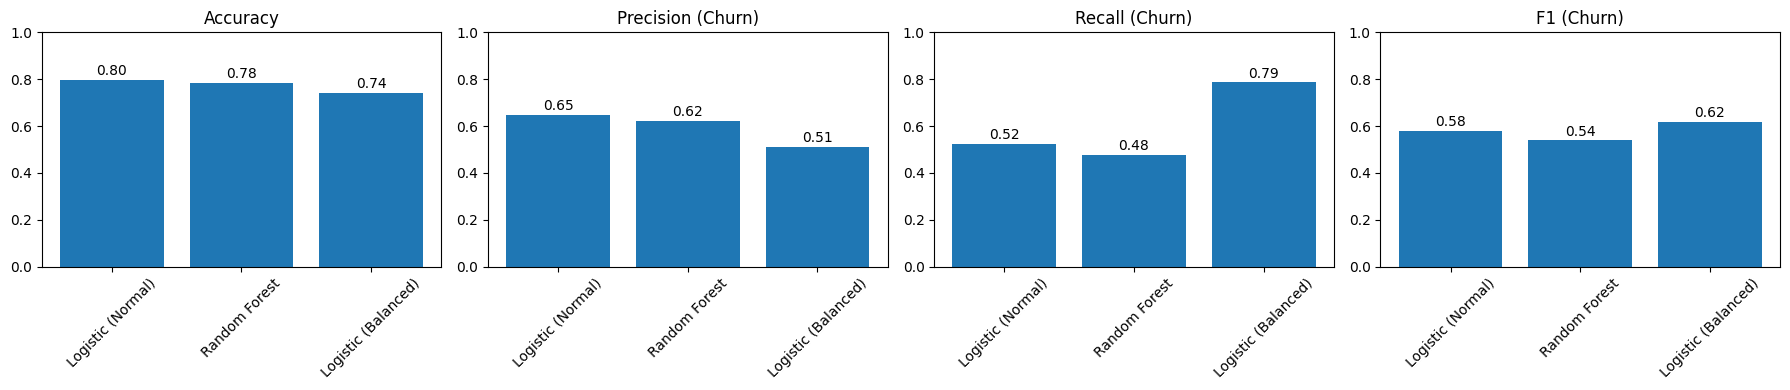

In [ ]:
resultados = {
    'Modelo': ['Logistic (Normal)', 'Random Forest', 'Logistic (Balanced)'],
    'Accuracy': [
        accuracy_score(y_test, y_pred_log_normal),
        accuracy_score(y_test, y_pred_rf),
        accuracy_score(y_test, y_pred_log)
    ],
    'Precision (Churn)': [
        precision_score(y_test, y_pred_log_normal, pos_label='Yes'),
        precision_score(y_test, y_pred_rf, pos_label='Yes'),
        precision_score(y_test, y_pred_log, pos_label='Yes')
    ],
    'Recall (Churn)': [
        recall_score(y_test, y_pred_log_normal, pos_label='Yes'),
        recall_score(y_test, y_pred_rf, pos_label='Yes'),
        recall_score(y_test, y_pred_log, pos_label='Yes')
    ],
    'F1 (Churn)': [
        f1_score(y_test, y_pred_log_normal, pos_label='Yes'),
        f1_score(y_test, y_pred_rf, pos_label='Yes'),
        f1_score(y_test, y_pred_log, pos_label='Yes')
    ]
}

df_comparacion = pd.DataFrame(resultados)
print("\n📊 COMPARACIÓN DE MODELOS")
print("="*70)
display(df_comparacion)

# Visualización
fig, axes = plt.subplots(1, 4, figsize=(18, 4))
metricas = ['Accuracy', 'Precision (Churn)', 'Recall (Churn)', 'F1 (Churn)']

for i, metrica in enumerate(metricas):
    axes[i].bar(df_comparacion['Modelo'], df_comparacion[metrica])
    axes[i].set_title(metrica)
    axes[i].set_ylim(0, 1)
    axes[i].tick_params(axis='x', rotation=45)

    # Añadir valores en barras
    for j, v in enumerate(df_comparacion[metrica]):
        axes[i].text(j, v + 0.02, f'{v:.2f}', ha='center')

plt.tight_layout()
plt.show()

# Curvas ROC — Comparación de Modelos

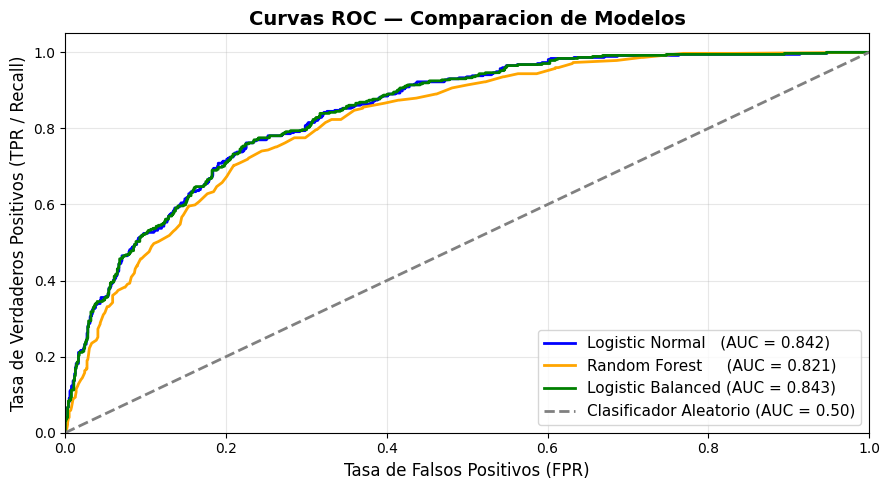


📈 RESUMEN AUC-ROC:
   Logistic Normal  : 0.842
   Random Forest    : 0.821
   Logistic Balanced: 0.843


In [ ]:
# PASO 1: Obtener probabilidades de todos los modelos
y_proba_log_normal   = log_model_normal.predict_proba(X_test)[:, 1]
y_proba_rf           = rf_model.predict_proba(X_test)[:, 1]
y_proba_log_balanced = log_model_balanced.predict_proba(X_test)[:, 1]

# PASO 2: Calcular curvas ROC
fpr_log_normal, tpr_log_normal, _ = roc_curve(y_test == 'Yes', y_proba_log_normal)
fpr_rf,         tpr_rf,         _ = roc_curve(y_test == 'Yes', y_proba_rf)
fpr_balanced,   tpr_balanced,   _ = roc_curve(y_test == 'Yes', y_proba_log_balanced)

# PASO 3: Calcular AUC
roc_auc_log_normal = auc(fpr_log_normal, tpr_log_normal)
roc_auc_rf         = auc(fpr_rf,         tpr_rf)
roc_auc_balanced   = auc(fpr_balanced,   tpr_balanced)

# PASO 4: Graficar comparación
plt.figure(figsize=(9, 5))

plt.plot(fpr_log_normal, tpr_log_normal, color='blue',   lw=2,
         label=f'Logistic Normal   (AUC = {roc_auc_log_normal:.3f})')
plt.plot(fpr_rf,         tpr_rf,         color='orange', lw=2,
         label=f'Random Forest     (AUC = {roc_auc_rf:.3f})')
plt.plot(fpr_balanced,   tpr_balanced,   color='green',  lw=2,
         label=f'Logistic Balanced (AUC = {roc_auc_balanced:.3f})')
plt.plot([0, 1], [0, 1], color='gray', lw=2, linestyle='--',
         label='Clasificador Aleatorio (AUC = 0.50)')

plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('Tasa de Falsos Positivos (FPR)', fontsize=12)
plt.ylabel('Tasa de Verdaderos Positivos (TPR / Recall)', fontsize=12)
plt.title('Curvas ROC — Comparacion de Modelos', fontsize=14, fontweight='bold')
plt.legend(loc="lower right", fontsize=11)
plt.grid(True, alpha=0.3)
plt.tight_layout()

# Guardar gráfico
plt.savefig(grafico +'/roc_comparacion_modelos.png', transparent=False, dpi=300, bbox_inches='tight')
plt.show()

# PASO 5: Resumen
print(f"\n📈 RESUMEN AUC-ROC:")
print(f"   Logistic Normal  : {roc_auc_log_normal:.3f}")
print(f"   Random Forest    : {roc_auc_rf:.3f}")
print(f"   Logistic Balanced: {roc_auc_balanced:.3f}")

# Validación Cruzada 5-Fold

In [ ]:
from sklearn.model_selection import cross_validate, StratifiedKFold
from sklearn.metrics import make_scorer, precision_score, recall_score, f1_score

print("="*80)
print("VALIDACIÓN CRUZADA (5-FOLD)")
print("="*80)

# Configurar validación cruzada estratificada
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# Modelo final a validar
modelo_cv = LogisticRegression(max_iter=1000, class_weight='balanced', random_state=42)

# Definir métricas a evaluar
scoring = {
    'accuracy': 'accuracy',
    'precision': make_scorer(precision_score, pos_label='Yes', zero_division=0),
    'recall':    make_scorer(recall_score,    pos_label='Yes', zero_division=0),
    'f1':        make_scorer(f1_score,        pos_label='Yes', zero_division=0),
    'roc_auc':   'roc_auc'
}

# Ejecutar validación cruzada
print("\n⏳ Ejecutando validación cruzada...")
cv_results = cross_validate(
    modelo_cv,
    X_train, y_train,
    cv=cv,
    scoring=scoring,
    return_train_score=True
)

print("Validación completada\n")

# Mostrar resultados
print("RESULTADOS DE VALIDACIÓN CRUZADA:")
print("-" * 80)

metricas_cv = ['accuracy', 'precision', 'recall', 'f1', 'roc_auc']

for metrica in metricas_cv:
    train_scores = cv_results[f'train_{metrica}']
    test_scores = cv_results[f'test_{metrica}']

    print(f"{metrica.upper():10s}:")
    print(f"   Train: {train_scores.mean():.3f} (+/- {train_scores.std():.3f})")
    print(f"   Test:  {test_scores.mean():.3f} (+/- {test_scores.std():.3f})")
    print(f"   Diff:  {train_scores.mean() - test_scores.mean():.3f}")
    print()

VALIDACIÓN CRUZADA (5-FOLD)

⏳ Ejecutando validación cruzada...
Validación completada

RESULTADOS DE VALIDACIÓN CRUZADA:
--------------------------------------------------------------------------------
ACCURACY  :
   Train: 0.753 (+/- 0.005)
   Test:  0.750 (+/- 0.012)
   Diff:  0.003

PRECISION :
   Train: 0.523 (+/- 0.007)
   Test:  0.519 (+/- 0.015)
   Diff:  0.004

RECALL    :
   Train: 0.800 (+/- 0.002)
   Test:  0.795 (+/- 0.013)
   Diff:  0.006

F1        :
   Train: 0.632 (+/- 0.005)
   Test:  0.628 (+/- 0.013)
   Diff:  0.005

ROC_AUC   :
   Train: 0.847 (+/- 0.004)
   Test:  0.843 (+/- 0.017)
   Diff:  0.004



# Importancia de Variables (Feature Importance)



# Ranking de Coeficientes — Logística Balanceada

In [ ]:
print("FEATURE IMPORTANCE - VARIABLES MÁS IMPORTANTES")

# Obtener coeficientes del modelo seleccionado (Logistic Balanced)
coeficientes = log_model_balanced.coef_[0]
nombres_features = X_train.columns

# Crear DataFrame
feature_importance = pd.DataFrame({
    'Feature': nombres_features,
    'Coeficiente': coeficientes,
    'Importancia_Abs': np.abs(coeficientes)
}).sort_values('Importancia_Abs', ascending=False)

print("\ TOP 15 VARIABLES MÁS IMPORTANTES:")
print(feature_importance.head(15).to_string(index=False))

FEATURE IMPORTANCE - VARIABLES MÁS IMPORTANTES
\ TOP 15 VARIABLES MÁS IMPORTANTES:
                       Feature  Coeficiente  Importancia_Abs
             Contract_Two year    -1.386755         1.386755
   InternetService_Fiber optic     1.314570         1.314570
            InternetService_No    -1.294736         1.294736
             Contract_One year    -0.708311         0.708311
               StreamingTV_Yes     0.504591         0.504591
PaymentMethod_Electronic check     0.429403         0.429403
           StreamingMovies_Yes     0.414177         0.414177
             MultipleLines_Yes     0.404301         0.404301
          PaperlessBilling_Yes     0.338989         0.338989
               TechSupport_Yes    -0.265910         0.265910
             SeniorCitizen_Yes     0.220128         0.220128
            OnlineSecurity_Yes    -0.180574         0.180574
                Dependents_Yes    -0.172093         0.172093
          DeviceProtection_Yes     0.088513         0.088513
  

<>:14: SyntaxWarning: invalid escape sequence '\ '
<>:14: SyntaxWarning: invalid escape sequence '\ '
/tmp/ipykernel_630/2746483702.py:14: SyntaxWarning: invalid escape sequence '\ '
  print("\ TOP 15 VARIABLES MÁS IMPORTANTES:")


# Visualización — Impacto de Variables en Churn

/tmp/ipykernel_630/1314430241.py:23: UserWarning: Glyph 128308 (\N{LARGE RED CIRCLE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_630/1314430241.py:23: UserWarning: Glyph 128994 (\N{LARGE GREEN CIRCLE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_630/1314430241.py:26: UserWarning: Glyph 128308 (\N{LARGE RED CIRCLE}) missing from font(s) DejaVu Sans.
  plt.savefig( grafico +'/feature_importance.png', transparent=False, dpi=300, bbox_inches='tight')
/tmp/ipykernel_630/1314430241.py:26: UserWarning: Glyph 128994 (\N{LARGE GREEN CIRCLE}) missing from font(s) DejaVu Sans.
  plt.savefig( grafico +'/feature_importance.png', transparent=False, dpi=300, bbox_inches='tight')
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 128308 (\N{LARGE RED CIRCLE}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserW

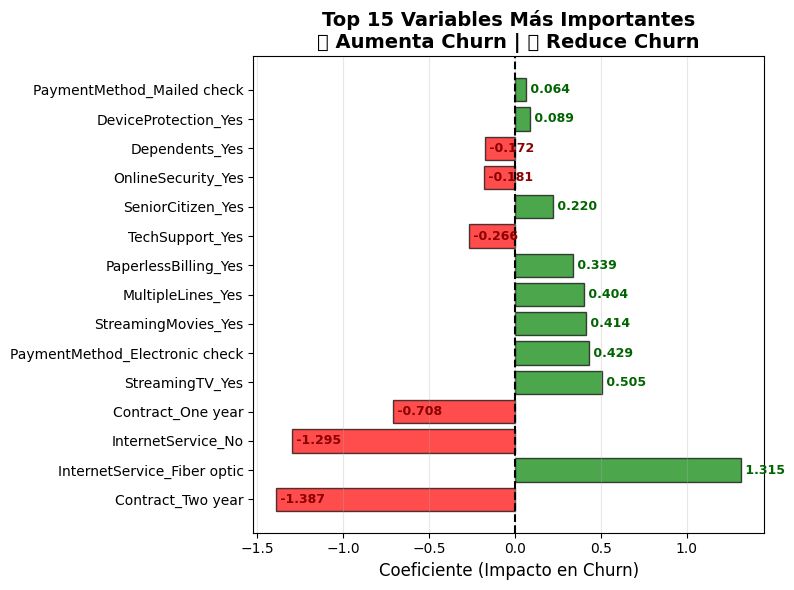

In [ ]:
plt.figure(figsize=(8, 6))

top_features = feature_importance.head(15)
colors = ['red' if x < 0 else 'green' for x in top_features['Coeficiente']]

plt.barh(range(len(top_features)), top_features['Coeficiente'],
         color=colors, alpha=0.7, edgecolor='black')
plt.yticks(range(len(top_features)), top_features['Feature'])
plt.xlabel('Coeficiente (Impacto en Churn)', fontsize=12)
plt.title('Top 15 Variables Más Importantes\n🔴 Aumenta Churn | 🟢 Reduce Churn',
          fontsize=14, fontweight='bold')
plt.axvline(x=0, color='black', linestyle='--', linewidth=1.5)
plt.grid(axis='x', alpha=0.3)

# Añadir valores
for i, (idx, row) in enumerate(top_features.iterrows()):
    value = row['Coeficiente']
    plt.text(value, i, f' {value:.3f}',
             va='center', fontsize=9,
             color='darkred' if value < 0 else 'darkgreen',
             fontweight='bold')

plt.tight_layout()

# Guardar gráfico
plt.savefig( grafico +'/feature_importance.png', transparent=False, dpi=300, bbox_inches='tight')

plt.show()

# Insights para el Negocio

In [ ]:

print("💡 INSIGHTS PARA EL NEGOCIO")

# Variables que aumentan churn
aumentan_churn = feature_importance[feature_importance['Coeficiente'] > 0].head(5)
print("\n🔴 TOP 5 VARIABLES QUE AUMENTAN CHURN:")
for idx, row in aumentan_churn.iterrows():
    print(f"   {row['Feature']:40s} → Coef: {row['Coeficiente']:+.3f}")

# Variables que reducen churn
reducen_churn = feature_importance[feature_importance['Coeficiente'] < 0].head(5)
print("\n🟢 TOP 5 VARIABLES QUE REDUCEN CHURN:")
for idx, row in reducen_churn.iterrows():
    print(f"   {row['Feature']:40s} → Coef: {row['Coeficiente']:+.3f}")


💡 INSIGHTS PARA EL NEGOCIO

🔴 TOP 5 VARIABLES QUE AUMENTAN CHURN:
   InternetService_Fiber optic              → Coef: +1.315
   StreamingTV_Yes                          → Coef: +0.505
   PaymentMethod_Electronic check           → Coef: +0.429
   StreamingMovies_Yes                      → Coef: +0.414
   MultipleLines_Yes                        → Coef: +0.404

🟢 TOP 5 VARIABLES QUE REDUCEN CHURN:
   Contract_Two year                        → Coef: -1.387
   InternetService_No                       → Coef: -1.295
   Contract_One year                        → Coef: -0.708
   TechSupport_Yes                          → Coef: -0.266
   OnlineSecurity_Yes                       → Coef: -0.181


# Entrenamiento del Modelo Final (Pipeline Completo)

In [ ]:
import joblib
import json
from datetime import datetime
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.linear_model import LogisticRegression

##  Función: Entrenar pipeline completo

In [ ]:
def entrenar_pipeline(X, y, cols_numericas, cols_categoricas):
    """
    Construye y entrena un pipeline completo que incluye
    preprocesamiento + modelo. Acepta datos crudos como entrada.

    Parámetros:
        X               : DataFrame con features sin procesar
        y               : Serie con variable objetivo
        cols_numericas  : Lista de columnas numéricas
        cols_categoricas: Lista de columnas categóricas

    Retorna:
        pipeline entrenado
    """
    preprocessor = ColumnTransformer(transformers=[
        ('num', 'passthrough', cols_numericas),
        ('cat', OneHotEncoder(
            drop='first',
            handle_unknown='ignore',
            sparse_output=False
        ), cols_categoricas)
    ])

    pipeline = Pipeline(steps=[
        ('preprocessor', preprocessor),
        ('classifier', LogisticRegression(
            max_iter=1000,
            class_weight='balanced',
            random_state=42
        ))
    ])

    pipeline.fit(X, y)
    return pipeline

# Serialización y Despliegue del Modelo

## Función: Serializar pipeline + metadata

In [ ]:
def serializar_pipeline(pipeline, X, y, cols_numericas, cols_categoricas):
    """
    Guarda el pipeline, los nombres de features y metadata en disco.

    Parámetros:
        pipeline        : Pipeline entrenado
        X               : DataFrame de features (sin procesar)
        y               : Serie con variable objetivo
        cols_numericas  : Lista de columnas numéricas
        cols_categoricas: Lista de columnas categóricas

    Retorna:
        dict con los nombres de archivos generados
    """
    timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")

    # Extraer nombres de features post-encoding
    feature_names = (
        cols_numericas +
        pipeline['preprocessor']
        .named_transformers_['cat']
        .get_feature_names_out(cols_categoricas).tolist()
    )

    # 1. Guardar pipeline completo
    filename_pipeline = f'pipeline_churn_telecom_{timestamp}.joblib'
    joblib.dump(pipeline, filename_pipeline)
    print(f"Pipeline guardado : {filename_pipeline}")

    # 2. Guardar feature names
    filename_features = f'feature_names_{timestamp}.joblib'
    joblib.dump(feature_names, filename_features)
    print(f"Features guardadas: {filename_features}")

    # 3. Guardar metadata
    metadata = {
        'fecha_entrenamiento' : timestamp,
        'fecha_legible'       : datetime.now().strftime("%d/%m/%Y %H:%M"),
        'n_observaciones'     : len(X),
        'n_features'          : len(feature_names),
        'algoritmo'           : 'LogisticRegression',
        'class_weight'        : 'balanced',
        'metricas_esperadas'  : {
            'recall'   : 0.79,
            'precision': 0.51,
            'f1'       : 0.62,
            'auc_roc'  : 0.84
        },
        'distribucion_churn': {
            'No' : int(y.value_counts()['No']),
            'Yes': int(y.value_counts()['Yes'])
        }
    }

    filename_metadata = f'metadata_{timestamp}.json'
    with open(filename_metadata, 'w') as f:
        json.dump(metadata, f, indent=4)
    print(f"Metadata guardada : {filename_metadata}")

    return {
        'pipeline' : filename_pipeline,
        'features' : filename_features,
        'metadata' : filename_metadata
    }

## Función: Predecir sobre datos crudos nuevos

In [ ]:
def predecir_nuevos_clientes(pipeline, nuevos_datos):
    """
    Realiza predicciones sobre datos crudos sin procesar.
    El pipeline internamente aplica el preprocesamiento.

    Parámetros:
        pipeline     : Pipeline entrenado y cargado
        nuevos_datos : DataFrame con las mismas columnas originales

    Retorna:
        DataFrame con predicción y probabilidad de churn
    """
    predicciones  = pipeline.predict(nuevos_datos)
    probabilidades = pipeline.predict_proba(nuevos_datos)[:, 1]

    resultado = nuevos_datos.copy()
    resultado['Churn_Predicho']     = predicciones
    resultado['Probabilidad_Churn'] = probabilidades.round(3)

    return resultado

# Ejecución de Modelo

In [ ]:
X_completo = datos.drop("Churn", axis=1)
y_completo = datos["Churn"]

cols_numericas    = ['Tenure', 'ChargesMonthly']
cols_categoricas  = [c for c in X_completo.columns if c not in cols_numericas]

# Entrenar
print("Entrenando pipeline completo...")
pipeline_final = entrenar_pipeline(X_completo, y_completo, cols_numericas, cols_categoricas)
print("Pipeline entrenado\n")

# Serializar
print("Serializando artefactos...")
archivos = serializar_pipeline(pipeline_final, X_completo, y_completo, cols_numericas, cols_categoricas)

# Verificar con datos crudos de muestra
print("\n Verificando predicción sobre datos crudos...")
muestra_cruda = X_completo.iloc[:3]
resultado = predecir_nuevos_clientes(pipeline_final, muestra_cruda)
print(resultado[['Tenure', 'ChargesMonthly', 'Churn_Predicho', 'Probabilidad_Churn']])

Entrenando pipeline completo...
Pipeline entrenado

Serializando artefactos...
Pipeline guardado : pipeline_churn_telecom_20260304_153800.joblib
Features guardadas: feature_names_20260304_153800.joblib
Metadata guardada : metadata_20260304_153800.json

 Verificando predicción sobre datos crudos...
   Tenure  ChargesMonthly Churn_Predicho  Probabilidad_Churn
0       9            65.6             No               0.335
1       9            59.9            Yes               0.638
2       4            73.9            Yes               0.845


In [ ]:
# import joblib
# 1. Cargar el pipeline (el "cerebro")
# Asegúrate de usar el nombre exacto de tu archivo generado
# model_path = '/content/pipeline_churn_telecom_20260304_012256.joblib'
# pipeline_cargado = joblib.load(model_path)

# 2. Crear o importar datos crudos (ejemplo de clientes nuevos)
# IMPORTANTE: Deben tener los mismos nombres de columnas originales
#nuevos_clientes = pd.DataFrame([
"""{
        'Tenure': 1,
        'ChargesMonthly': 105.5,
        'SeniorCitizen': 'Yes',
        'Partner': 'No',
        'Dependents': 'No',
        'MultipleLines': 'Yes',
        'InternetService': 'Fiber optic',
        'OnlineSecurity': 'No',
        'OnlineBackup': 'No',
        'DeviceProtection': 'No',
        'TechSupport': 'No',
        'StreamingTV': 'Yes',
        'StreamingMovies': 'Yes',
        'Contract': 'Month-to-month',
        'PaperlessBilling': 'Yes',
        'PaymentMethod': 'Electronic check'
    }
])"""

# 3. Obtener la probabilidad directamente
#probabilidades = pipeline_cargado.predict_proba(nuevos_clientes)[:, 1]

#print(f"La probabilidad de que este cliente se vaya es: {probabilidades[0]:.2%}")

"{\n        'Tenure': 1,\n        'ChargesMonthly': 105.5,\n        'SeniorCitizen': 'Yes',\n        'Partner': 'No',\n        'Dependents': 'No',\n        'MultipleLines': 'Yes',\n        'InternetService': 'Fiber optic',\n        'OnlineSecurity': 'No',\n        'OnlineBackup': 'No',\n        'DeviceProtection': 'No',\n        'TechSupport': 'No',\n        'StreamingTV': 'Yes',\n        'StreamingMovies': 'Yes',\n        'Contract': 'Month-to-month',\n        'PaperlessBilling': 'Yes',\n        'PaymentMethod': 'Electronic check'\n    }\n])"

# Conclusión Estratégica

In [ ]:
print("=" * 60)
print("📋 CONCLUSIÓN ESTRATÉGICA — TELECOM X")
print("=" * 60)

conclusión = """

1. DESEMPEÑO DE LOS MODELOS

Se entrenaron tres modelos de clasificación para predecir la cancelación de
clientes (Churn). Los resultados obtenidos fueron:

  • Logistic Regression (Normal)  → Accuracy: 80% | AUC-ROC: 0.843 | F1: 0.58
  • Random Forest                 → Accuracy: 78% | AUC-ROC: 0.821 | F1: 0.54
  • Logistic Regression (Balanced)→ Accuracy: 74% | AUC-ROC: 0.843 | F1: 0.62

El modelo seleccionado como FINAL fue la Regresión Logística Balanceada,
por las siguientes razones:

  → Mayor Recall (0.79): detecta correctamente al 79% de los clientes que
    realmente van a cancelar. En un problema de churn, no detectar a un cliente
    en riesgo tiene un costo mayor que una falsa alarma.

  → AUC-ROC de 0.843: igual al modelo normal, pero con mejor cobertura
    sobre la clase minoritaria (Churn = Yes).

  → Validación cruzada estable (5-Fold): diferencia Train/Test menor a 0.006
    en todas las métricas, lo que confirma que el modelo generaliza bien y
    no presenta overfitting.


2. PRINCIPALES FACTORES QUE INFLUYEN EN LA CANCELACIÓN

A partir del análisis de correlación, el test Chi-cuadrado y el Feature
Importance del modelo final, se identificaron los siguientes factores:

  🔴 FACTORES QUE AUMENTAN EL RIESGO DE CANCELACIÓN:

  1. Internet Fiber Optic (Coef: +1.315)
     Es el factor de mayor riesgo después del contrato. Los clientes con
     fibra óptica cancelan al 42% vs 19% en DSL. Posible causa: expectativas
     de calidad no satisfechas o precio percibido como injusto.

  2. Contrato Month-to-Month
     El 42.7% de clientes con contrato mensual cancela, frente al 2.8% con
     contrato de dos años. La falta de compromiso contractual es el predictor
     más poderoso de churn en el dataset.

  3. Pago por Electronic Check (Coef: +0.429)
     El 45.3% de clientes que pagan con cheque electrónico cancelan — la tasa
     más alta de todos los métodos de pago. Puede indicar un perfil de cliente
     menos fidelizado o con menor automatización financiera.

  4. Servicios de Streaming — TV y Películas (Coef: +0.505 / +0.414)
     Clientes con streaming tienen mayor churn (~30%) que los que no lo
     tienen (~24%). Son servicios de alto costo percibido y fácilmente
     sustituibles por competidores.

  5. Clientes nuevos (Tenure bajo)
     Los primeros meses son el período de mayor vulnerabilidad. Clientes con
     menos de 12 meses presentan las tasas de cancelación más elevadas.

  🟢 FACTORES QUE REDUCEN EL RIESGO DE CANCELACIÓN:

  1. Contrato Two Year (Coef: -1.387)
     El factor protector más fuerte. Solo el 2.8% de estos clientes cancela.
     Migrar clientes a contratos largos es la palanca de retención más efectiva.

  2. Sin Servicio de Internet (Coef: -1.295)
     Estos clientes tienen la menor tasa de churn (7.4%). Son un segmento
     estable, aunque de menor valor para el negocio.

  3. Contrato One Year (Coef: -0.708)
     Tasa de cancelación del 11.3% — intermedia pero significativamente mejor
     que el contrato mensual. Representa un escalón viable de fidelización.

  4. Tech Support activo (Coef: -0.266)
     Clientes con soporte técnico cancelan menos (15% vs 31%). El soporte
     genera percepción de valor y reduce la frustración operativa.

  5. Online Security activo (Coef: -0.181)
     Similar al soporte técnico — los servicios de valor agregado aumentan
     la permanencia del cliente.


3. RECOMENDACIONES ESTRATÉGICAS PARA EL NEGOCIO


  📌 R1 — Migración a contratos anuales o bianuales
     Diseñar incentivos (descuentos, beneficios exclusivos) para que clientes
     con contrato mensual migren a contratos más largos. Es la acción con
     mayor impacto comprobado en retención.

  📌 R2 — Programa de atención temprana (primeros 12 meses)
     Implementar un protocolo de onboarding activo para clientes nuevos:
     contacto proactivo, tutoriales, ofertas de permanencia. Los datos
     muestran que este período es el de mayor riesgo.

  📌 R3 — Investigar calidad del servicio Fiber Optic
     La alta tasa de churn en fibra óptica sugiere un problema de calidad o
     expectativas. Se recomienda encuestas de NPS segmentadas por tipo de
     internet para identificar la causa raíz.

  📌 R4 — Promover servicios de valor agregado
     Incentivar la adopción de Tech Support y Online Security en clientes
     vulnerables (contrato mensual + fibra óptica). Estos servicios actúan
     como ancla de fidelización.

  📌 R5 — Atención focalizada en clientes de Electronic Check
     Este segmento tiene la mayor tasa de churn. Se puede intervenir
     ofreciendo incentivos para migrar a pagos automáticos (débito o
     tarjeta de crédito), que estadísticamente se asocian a mayor retención.

4. PERFIL DEL CLIENTE EN ALTO RIESGO DE CHURN

  Un cliente con ALTA probabilidad de cancelar típicamente presenta:

  ✗ Contrato Month-to-Month
  ✗ Servicio de Internet Fiber Optic
  ✗ Método de pago: Electronic Check
  ✗ Sin Tech Support ni Online Security contratados
  ✗ Menos de 12 meses como cliente (Tenure bajo)
  ✗ Servicios de Streaming activos (TV y/o Películas)

  → Este perfil debe ser priorizado por el equipo de retención para
    intervención proactiva antes de que se concrete la cancelación.


5. LIMITACIONES Y PRÓXIMOS PASOS


  ⚠ El modelo fue entrenado con datos históricos — requiere reentrenamiento
    periódico a medida que el comportamiento del cliente evolucione.

  ⚠ El desbalance de clases (73% No Churn / 27% Churn) fue tratado con
    class_weight='balanced', pero técnicas como SMOTE podrían explorarse
    en iteraciones futuras para mejorar el Recall.

  ⚠ Variables externas no consideradas (competencia, precios de mercado,
    satisfacción del servicio) podrían enriquecer el modelo en una siguiente
    fase.

  🔜 Próximos pasos sugeridos:
     → Explorar XGBoost o LightGBM para comparar rendimiento
     → Ajuste de umbral de decisión (threshold tuning) según costo de negocio
     → Implementar sistema de scoring mensual automático sobre cartera activa
"""

print(conclusion)

📋 CONCLUSIÓN ESTRATÉGICA — TELECOM X

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
1. DESEMPEÑO DE LOS MODELOS
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

Se entrenaron tres modelos de clasificación para predecir la cancelación de
clientes (Churn). Los resultados obtenidos fueron:

  • Logistic Regression (Normal)  → Accuracy: 80% | AUC-ROC: 0.843 | F1: 0.58
  • Random Forest                 → Accuracy: 78% | AUC-ROC: 0.821 | F1: 0.54
  • Logistic Regression (Balanced)→ Accuracy: 74% | AUC-ROC: 0.843 | F1: 0.62

El modelo seleccionado como FINAL fue la Regresión Logística Balanceada,
por las siguientes razones:

  → Mayor Recall (0.79): detecta correctamente al 79% de los clientes que
    realmente van a cancelar. En un problema de churn, no detectar a un cliente
    en riesgo tiene un costo mayor que una falsa alarma.

  → AUC-ROC de 0.843: igual al modelo normal, pero con mejor cobertura
    sobre la clase minorita